In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor


In [2]:
df = pd.read_csv("yield_df.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop("Unnamed: 0", axis=1)

print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nColumns:\n", df.columns)

df.info()
df.head()
df.describe()

Dataset Shape: (28242, 7)

Missing Values:
 Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

Columns:
 Index(['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           28242 non-null  object 
 1   Item                           28242 non-null  object 
 2   Year                           28242 non-null  int64  
 3   hg/ha_yield                    28242 non-null  int64  
 4   average_rain_fall_mm_per_year  28242 non-null  float64
 5   pesticides_t

,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,2013.000000,501412.000000,3240.00000,367778.000000,30.650000



===== EDA STARTED =====

Shape of dataset: (28242, 7)

Columns: ['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']


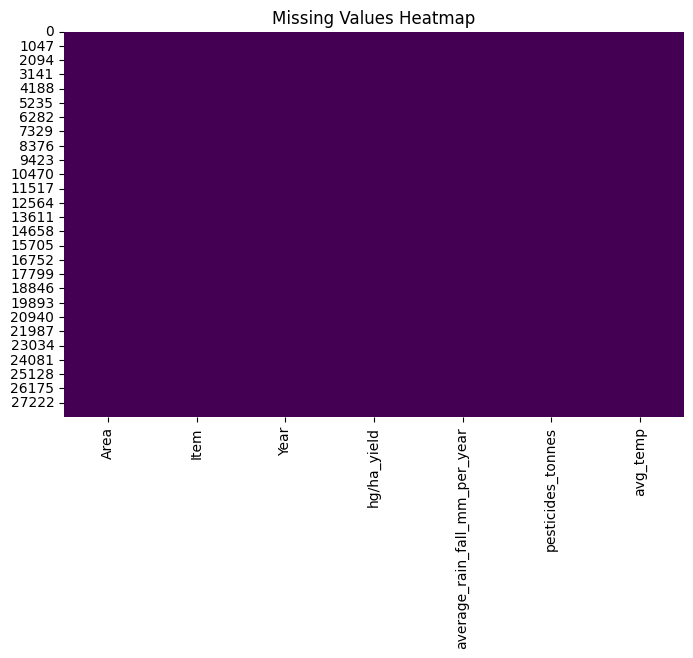

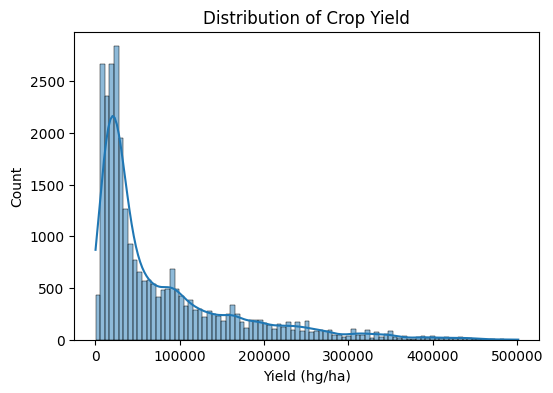

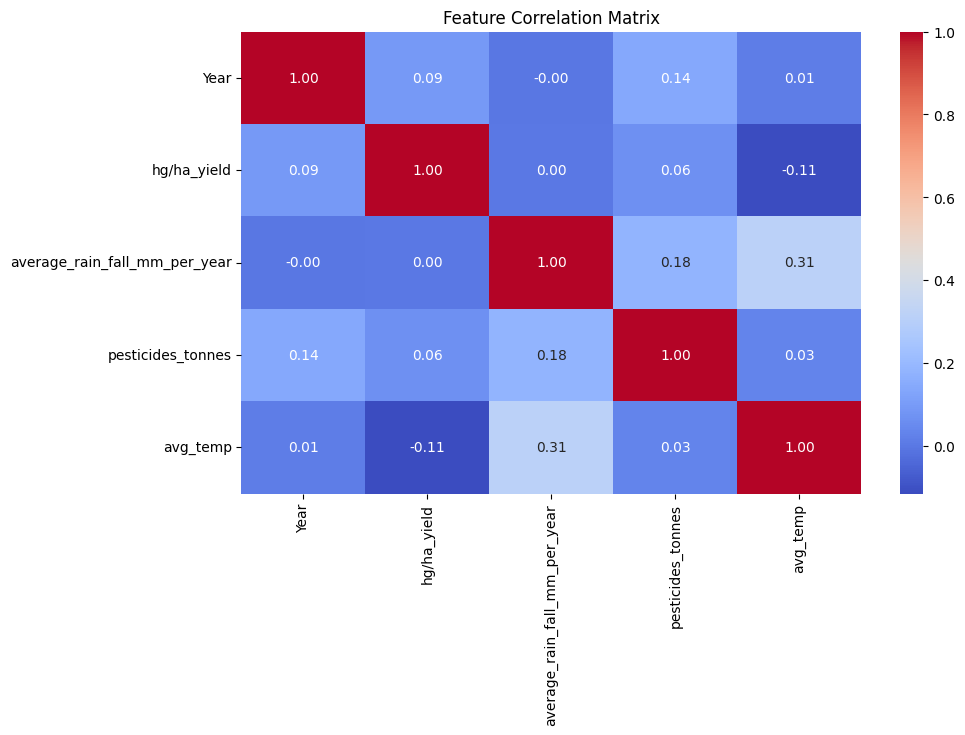

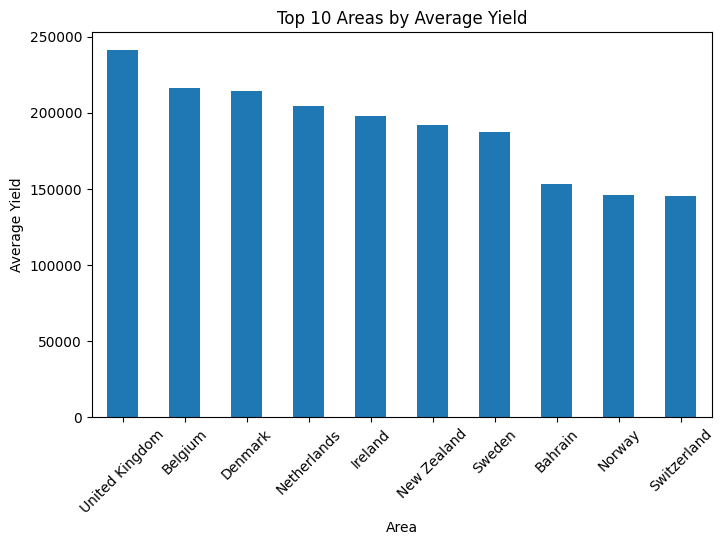

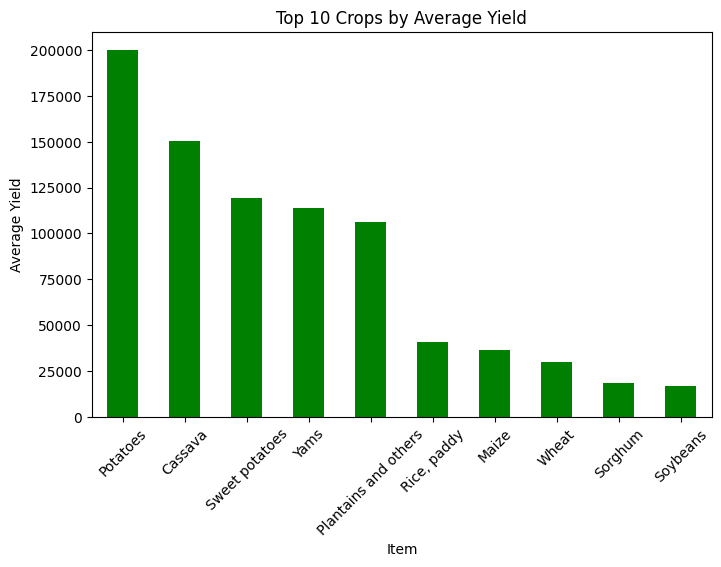

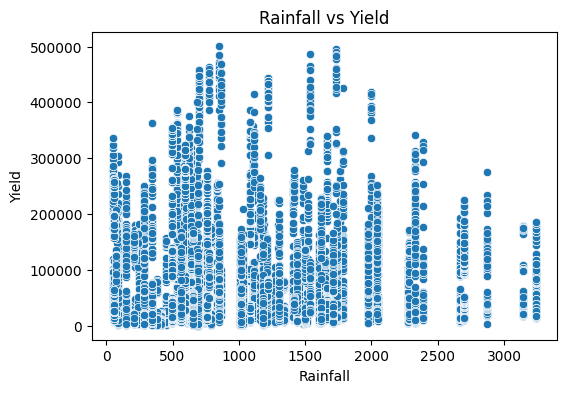

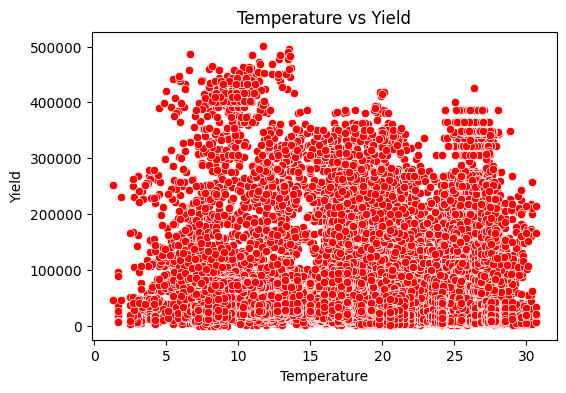


===== EDA COMPLETED =====



In [4]:
# -----------------------------------------
# 📊 EXPLORATORY DATA ANALYSIS (EDA)
# -----------------------------------------

print("\n===== EDA STARTED =====\n")

# 1. Dataset Overview
print("Shape of dataset:", df.shape)
print("\nColumns:", df.columns.tolist())

# 2. Missing Values Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

# 3. Distribution of Target Variable
plt.figure(figsize=(6,4))
sns.histplot(df['hg/ha_yield'], kde=True)
plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (hg/ha)")
plt.show()

# 4. Correlation Matrix
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

# 5. Top Crop Producing Areas
top_areas = df.groupby('Area')['hg/ha_yield'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_areas.plot(kind='bar')
plt.title("Top 10 Areas by Average Yield")
plt.ylabel("Average Yield")
plt.xticks(rotation=45)
plt.show()

# 6. Top Crops by Yield
top_crops = df.groupby('Item')['hg/ha_yield'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_crops.plot(kind='bar', color='green')
plt.title("Top 10 Crops by Average Yield")
plt.ylabel("Average Yield")
plt.xticks(rotation=45)
plt.show()

# 7. Rainfall vs Yield
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['average_rain_fall_mm_per_year'], y=df['hg/ha_yield'])
plt.title("Rainfall vs Yield")
plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.show()

# 8. Temperature vs Yield
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['avg_temp'], y=df['hg/ha_yield'], color='red')
plt.title("Temperature vs Yield")
plt.xlabel("Temperature")
plt.ylabel("Yield")
plt.show()

print("\n===== EDA COMPLETED =====\n")

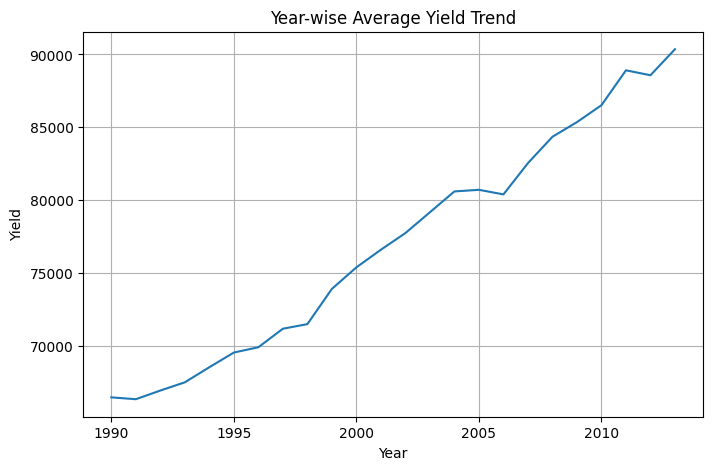

In [5]:
# Year vs Yield Trend
year_trend = df.groupby('Year')['hg/ha_yield'].mean()

plt.figure(figsize=(8,5))
year_trend.plot()
plt.title("Year-wise Average Yield Trend")
plt.xlabel("Year")
plt.ylabel("Yield")
plt.grid()
plt.show()

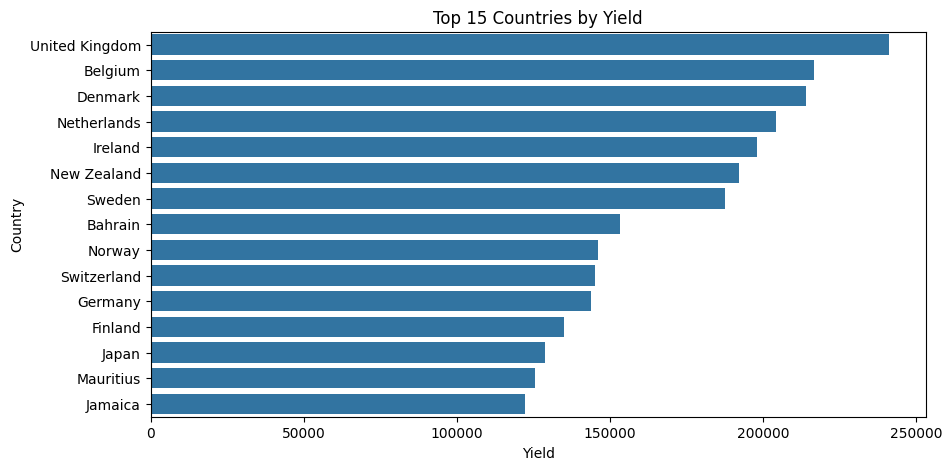

In [6]:
top_countries = df.groupby('Area')['hg/ha_yield'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 15 Countries by Yield")
plt.xlabel("Yield")
plt.ylabel("Country")
plt.show()

In [5]:
le_area = LabelEncoder()
le_item = LabelEncoder()

df['Area'] = le_area.fit_transform(df['Area'])
df['Item'] = le_item.fit_transform(df['Item'])

In [6]:
X = df.drop('hg/ha_yield', axis=1)
y = df['hg/ha_yield']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

In [7]:
models = {
    "SVR":            SVR(kernel='rbf', C=100, epsilon=0.1),      # ✅ Paper's best model
    "KNN Regressor":  KNeighborsRegressor(n_neighbors=5),          # ✅ Added
    "XGBoost":        XGBRegressor(n_estimators=200,
                                    random_state=42,
                                    verbosity=0),                   # ✅ Added
    "Random Forest":  RandomForestRegressor(n_estimators=200,
                                             random_state=42),
    "Decision Tree":  DecisionTreeRegressor(random_state=42)
}

results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results[name] = {
        "R2 Score": round(r2, 4),
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2)
    }

    trained_models[name] = model

results_df = pd.DataFrame(results).T.sort_values(by="R2 Score", ascending=False)

print("\n📊 Model Comparison:\n")
print(results_df)



📊 Model Comparison:

               R2 Score       MAE      RMSE
Random Forest    0.9849   3979.48  10579.78
XGBoost          0.9781   6910.27  12731.03
Decision Tree    0.9716   4263.48  14505.89
KNN Regressor    0.9071  12474.93  26234.13
SVR             -0.1086  54883.17  90649.63


In [8]:
best_model_name = results_df.index[0]
model = trained_models[best_model_name]

print(f"\n🏆 Best Model Selected: {best_model_name}")


🏆 Best Model Selected: Random Forest


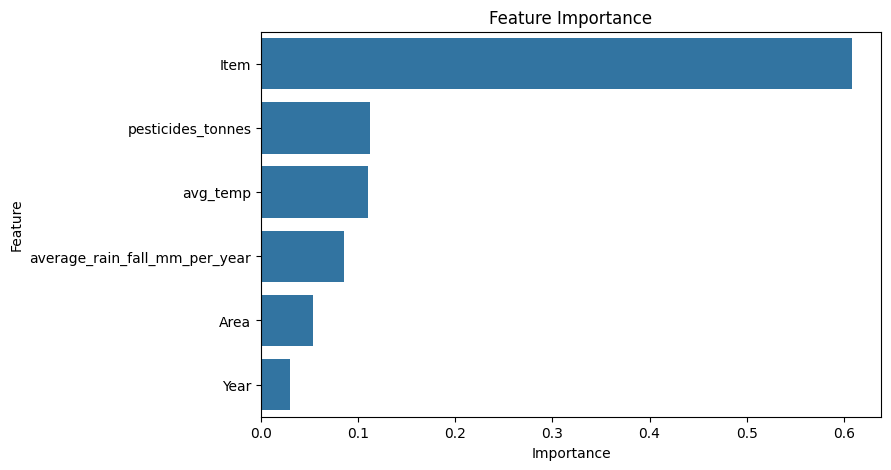

In [9]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

importances = rf_model.feature_importances_
feature_names = X.columns

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title("Feature Importance")
plt.show()

In [10]:
results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2   = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    std  = np.std(y_test - y_pred)       # ✅ Added STD

    results[name] = {
        "R2 Score":  round(r2, 4),
        "MAE":       round(mae, 2),
        "MSE":       round(mse, 2),
        "RMSE":      round(rmse, 4),
        "Std Dev":   round(std, 2)        # ✅ Added
    }
    trained_models[name] = model

results_df = pd.DataFrame(results).T.sort_values(
                by="R2 Score", ascending=False)
print("\n📊 Model Comparison:\n")
print(results_df)


📊 Model Comparison:

               R2 Score       MAE           MSE        RMSE   Std Dev
Random Forest    0.9849   3979.48  1.119318e+08  10579.7832  10579.78
XGBoost          0.9781   6910.27  1.620790e+08  12731.0260  12731.01
Decision Tree    0.9716   4263.48  2.104208e+08  14505.8879  14505.66
KNN Regressor    0.9071  12474.93  6.882294e+08  26234.1266  26228.72
SVR             -0.1086  54883.17  8.217356e+09  90649.6321  82910.52


In [11]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Apply MICE on numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns

mice_imputer = IterativeImputer(max_iter=10, random_state=42)
df[numeric_cols] = mice_imputer.fit_transform(df[numeric_cols])

print("✅ MICE Imputation completed. Missing values after:")
print(df.isnull().sum())

✅ MICE Imputation completed. Missing values after:
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64


In [12]:
print("\nAvailable Areas:\n", le_area.classes_)
print("\nAvailable Crops:\n", le_item.classes_)

def predict_yield(Area, Item, Year,
                  average_rain_fall_mm_per_year,
                  pesticides_tonnes,
                  avg_temp):

    # Remove extra spaces
    Area = Area.strip()
    Item = Item.strip()

    # Case-insensitive matching
    area_dict = {a.lower(): a for a in le_area.classes_}
    item_dict = {i.lower(): i for i in le_item.classes_}

    if Area.lower() not in area_dict:
        raise ValueError("❌ Area not found in dataset.")

    if Item.lower() not in item_dict:
        raise ValueError("❌ Item not found in dataset.")

    Area_corrected = area_dict[Area.lower()]
    Item_corrected = item_dict[Item.lower()]

    # Encode
    area_encoded = le_area.transform([Area_corrected])[0]
    item_encoded = le_item.transform([Item_corrected])[0]

    # Create input DataFrame
    input_df = pd.DataFrame({
        "Area": [area_encoded],
        "Item": [item_encoded],
        "Year": [Year],
        "average_rain_fall_mm_per_year": [average_rain_fall_mm_per_year],
        "pesticides_tonnes": [pesticides_tonnes],
        "avg_temp": [avg_temp]
    })

    # Match training feature order
    input_df = input_df[X.columns]

    # Scale
    input_scaled = scaler.transform(input_df)

    # Predict
    prediction = model.predict(input_scaled)

    return prediction[0]



Available Areas:
 ['Albania' 'Algeria' 'Angola' 'Argentina' 'Armenia' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Belarus' 'Belgium'
 'Botswana' 'Brazil' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cameroon'
 'Canada' 'Central African Republic' 'Chile' 'Colombia' 'Croatia'
 'Denmark' 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Eritrea'
 'Estonia' 'Finland' 'France' 'Germany' 'Ghana' 'Greece' 'Guatemala'
 'Guinea' 'Guyana' 'Haiti' 'Honduras' 'Hungary' 'India' 'Indonesia' 'Iraq'
 'Ireland' 'Italy' 'Jamaica' 'Japan' 'Kazakhstan' 'Kenya' 'Latvia'
 'Lebanon' 'Lesotho' 'Libya' 'Lithuania' 'Madagascar' 'Malawi' 'Malaysia'
 'Mali' 'Mauritania' 'Mauritius' 'Mexico' 'Montenegro' 'Morocco'
 'Mozambique' 'Namibia' 'Nepal' 'Netherlands' 'New Zealand' 'Nicaragua'
 'Niger' 'Norway' 'Pakistan' 'Papua New Guinea' 'Peru' 'Poland' 'Portugal'
 'Qatar' 'Romania' 'Rwanda' 'Saudi Arabia' 'Senegal' 'Slovenia'
 'South Africa' 'Spain' 'Sri Lanka' 'Sudan' 'Suriname' 'Sweden'
 'Switz

In [13]:
print("\nEnter Details for Yield Prediction :")

Area = input("Area: ")
Item = input("Item (Crop): ")
Year = int(input("Year (e.g., 2027): "))
average_rain_fall_mm_per_year = float(input("Average Rainfall (mm per year): "))
pesticides_tonnes = float(input("Pesticides (tonnes): "))
avg_temp = float(input("Average Temperature: "))

predicted_yield = predict_yield(
    Area=Area,
    Item=Item,
    Year=Year,
    average_rain_fall_mm_per_year=average_rain_fall_mm_per_year,
    pesticides_tonnes=pesticides_tonnes,
    avg_temp=avg_temp
)

print("\n🌾 Predicted Yield (hg/ha):", round(predicted_yield, 2))


Enter Details for Yield Prediction :


Area:  india
Item (Crop):  rice
Year (e.g., 2027):  2026
Average Rainfall (mm per year):  32
Pesticides (tonnes):  43
Average Temperature:  30


ValueError: ❌ Item not found in dataset.